In [4]:
from google.colab import files

uploaded = files.upload()

Saving archive (6).zip to archive (6) (1).zip


In [5]:
import zipfile
import os

zip_file = "archive (6).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("project2_data")

print(os.listdir("project2_data"))

['creditcard.csv']


In [6]:
df = pd.read_csv("project2_data/creditcard.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
print("Column Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['Class'].value_counts())

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (227845, 30)
Testing set: (56962, 30)

Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing class distribution:
Class
0    56864
1       98
Name: count, dtype: int64


In [9]:
!pip install imbalanced-learn -q

In [10]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nTraining data shape after SMOTE:")
print(X_train_smote.shape)

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Training data shape after SMOTE:
(454902, 30)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train_smote)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [13]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

# Make predictions on test data
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Get probability scores for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Precision:", precision_logistic)
print("Recall:", recall_logistic)
print("ROC-AUC:", roc_auc_logistic)

Logistic Regression Results
---------------------------
Precision: 0.13414634146341464
Recall: 0.8979591836734694
ROC-AUC: 0.9764816590676788


In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model on SMOTE-balanced training data
random_forest_model.fit(X_train_smote, y_train_smote)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [15]:
# Make predictions on test data
y_pred_rf = random_forest_model.predict(X_test)

# Get probability scores for ROC-AUC
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("ROC-AUC:", roc_auc_rf)

Random Forest Results
---------------------
Precision: 0.826530612244898
Recall: 0.826530612244898
ROC-AUC: 0.9644234399584257


In [16]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [precision_logistic, precision_rf],
    'Recall': [recall_logistic, recall_rf],
    'ROC-AUC': [roc_auc_logistic, roc_auc_rf]
})

results

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.134146,0.897959,0.976482
1,Random Forest,0.826531,0.826531,0.964423


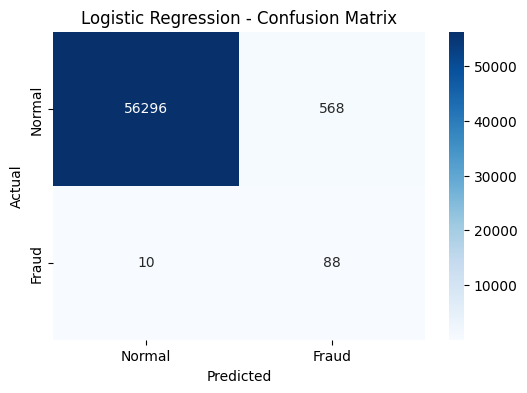

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

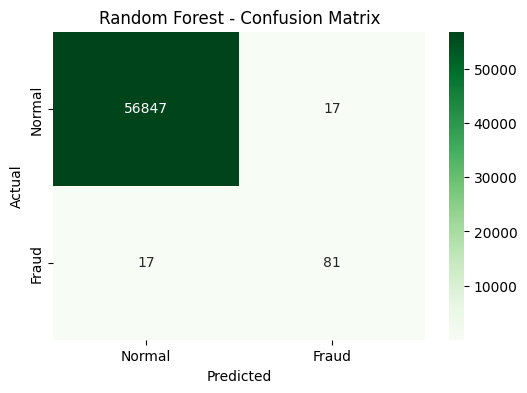

In [19]:
# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()

In [23]:
tuned_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

tuned_rf.fit(X_train_smote, y_train_smote)

print("Tuned Random Forest trained successfully!")

Tuned Random Forest trained successfully!


In [24]:
# Predictions using tuned Random Forest
y_pred_tuned_rf = tuned_rf.predict(X_test)

# Probability scores for ROC-AUC
y_prob_tuned_rf = tuned_rf.predict_proba(X_test)[:, 1]

# Calculate metrics
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
roc_auc_tuned_rf = roc_auc_score(y_test, y_prob_tuned_rf)

print("Tuned Random Forest Results")
print("---------------------------")
print("Precision:", precision_tuned_rf)
print("Recall:", recall_tuned_rf)
print("ROC-AUC:", roc_auc_tuned_rf)

Tuned Random Forest Results
---------------------------
Precision: 0.5304878048780488
Recall: 0.8877551020408163
ROC-AUC: 0.9818549342218599


In [25]:
final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'Precision': [
        precision_logistic,
        precision_rf,
        precision_tuned_rf
    ],
    'Recall': [
        recall_logistic,
        recall_rf,
        recall_tuned_rf
    ],
    'ROC-AUC': [
        roc_auc_logistic,
        roc_auc_rf,
        roc_auc_tuned_rf
    ]
})

final_results

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.134146,0.897959,0.976482
1,Random Forest,0.826531,0.826531,0.964423
2,Tuned Random Forest,0.530488,0.887755,0.981855


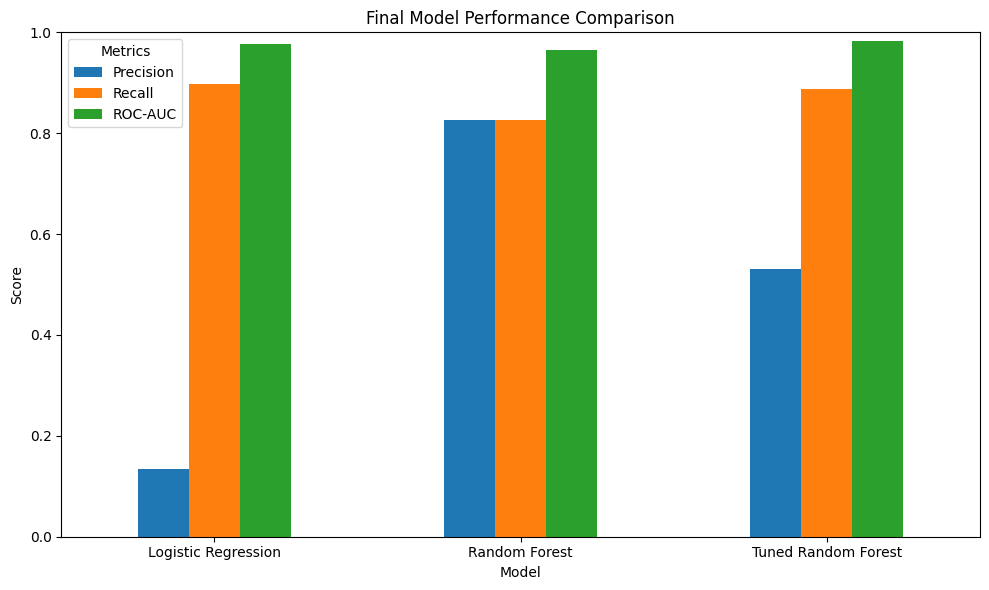

In [26]:
import matplotlib.pyplot as plt

final_results.set_index('Model')[['Precision', 'Recall', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Final Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

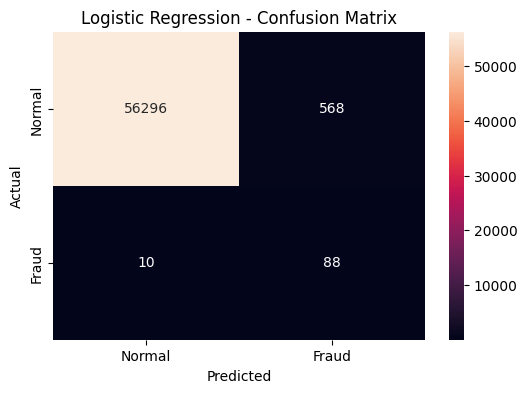

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

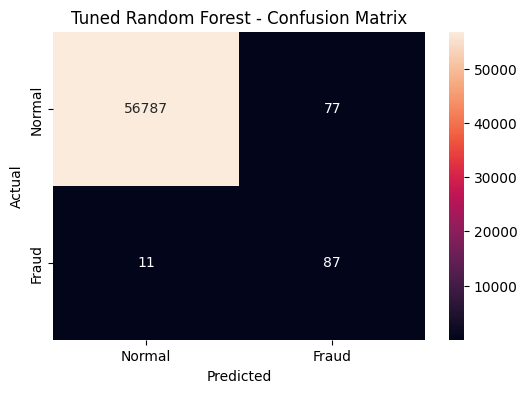

In [28]:
cm_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_tuned_rf,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Random Forest - Confusion Matrix')
plt.show()

In [29]:
final_results

,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.134146,0.897959,0.976482
1,Random Forest,0.826531,0.826531,0.964423
2,Tuned Random Forest,0.530488,0.887755,0.981855


## Conclusion

In this project, a supervised machine learning pipeline was developed for credit card fraud detection. The dataset contained 284,807 transactions and was highly imbalanced, with only 492 fraudulent transactions.

The data was divided into training and testing sets using stratified splitting. SMOTE was then applied only to the training data to handle class imbalance.

Three classification approaches were evaluated: Logistic Regression, Random Forest, and Tuned Random Forest. The models were evaluated using Precision, Recall, and ROC-AUC.

The Tuned Random Forest achieved a Precision of 0.5305, Recall of 0.8878, and ROC-AUC of 0.9819 on the test dataset. The confusion matrix showed that it correctly detected 87 fraudulent transactions while missing 11 fraudulent transactions.

Overall, the project demonstrates the application of supervised learning, SMOTE, Random Forest classification, hyperparameter tuning, and appropriate evaluation metrics for an imbalanced fraud detection problem.
## Key Skills Demonstrated

- Data preprocessing
- Class imbalance analysis
- Train-test splitting
- SMOTE
- Logistic Regression
- Random Forest
- Hyperparameter tuning
- Precision
- Recall
- ROC-AUC
- Confusion Matrix